In [1]:
import os
import dask
import glob
import pyproj
import xesmf as xe
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
ProgressBar().register()

### Optional: Process data

In [4]:
# Define target output grid (0.25° lat/lon)
lat_out = np.arange(30, 90.25, 0.25)
lon_out = np.arange(-180, 180.25, 0.25)
target_grid = xr.Dataset({'lat': (['lat'], lat_out), 'lon': (['lon'], lon_out)})

# Cache to store lat/lon for known grid shapes
grid_cache = {}

# Polar Stereographic projection used by datasets
proj = pyproj.Proj(proj='stere', lat_ts=70, lat_0=90, lon_0=0, datum='WGS84')

# Find all input files
file_paths = sorted(glob.glob('/pscratch/sd/s/skygale/pbi-data/*'))

for file_path in file_paths:
    print(f"Processing {file_path}")
    ds = xr.open_dataset(file_path, chunks="auto")

    # Rename dims if needed
    if 'ni' in ds.dims and 'nj' in ds.dims:
        ds = ds.rename({'ni': 'x', 'nj': 'y'})

    # Add lat/lon coordinates if missing
    if 'lat' in ds.coords and 'lon' in ds.coords:
        shape = ds['lat'].shape
        if shape not in grid_cache:
            grid_cache[shape] = (ds['lat'], ds['lon'])
    else:
        shape = (ds.dims['y'], ds.dims['x'])
        if shape in grid_cache:
            lat, lon = grid_cache[shape]
        elif 'x' in ds.coords and 'y' in ds.coords:
            x = ds['x'].values
            y = ds['y'].values
            xx, yy = np.meshgrid(x, y)
            lon, lat = proj(xx, yy, inverse=True)
            grid_cache[shape] = (lat, lon)
        else:
            print("Missing spatial coordinates, skipping file.")
            continue
        ds = ds.assign_coords(lat=(('y', 'x'), lat), lon=(('y', 'x'), lon))

    # Find sea ice variable
    varname = next((v for v in ds.data_vars if 'ice' in v.lower() or 'sic' in v.lower()), None)
    if varname is None:
        print("No sea ice variable found, skipping file.")
        continue

    # Regrid
    ds = ds.transpose('time', 'y', 'x', ...)
    
    regridder = xe.Regridder(
        ds,
        target_grid,
        method='bilinear',
        periodic=True,
        reuse_weights=False
    )
    
    # Apply regridding with specified output chunks
    regridded = regridder(ds[varname], output_chunks={'time': 30, 'lat': 90, 'lon': 90})
    
    # Add time and derived coordinates
    regridded = regridded.assign_coords(time=ds.time)
    regridded = regridded.assign_coords(
        year=ds.time.dt.year,
        month=ds.time.dt.month,
        day=ds.time.dt.day
    )
    
    # Convert to dataset and save
    ds_out = regridded.to_dataset(name=varname)
    ds_out = ds_out.chunk({'time': 30, 'lat': 90, 'lon': 90})
    out_path = file_path.replace('.nc', '_regridded.nc')
    encoding = {varname: {"zlib": False}}
    
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    print(f'--> Saving to {out_path}')
    with ProgressBar():
        ds_out.to_netcdf(out_path, encoding=encoding, engine='netcdf4', mode='w', compute=True)

Processing /pscratch/sd/s/skygale/pbi-data/AMSR2_12.5km_2012_Present.nc
[########################################] | 100% Completed | 101.24 ms
[########################################] | 100% Completed | 101.85 ms
--> Saving to /pscratch/sd/s/skygale/pbi-data/AMSR2_12.5km_2012_Present_regridded.nc


PermissionError: [Errno 13] Permission denied: '/pscratch/sd/s/skygale/pbi-data/AMSR2_12.5km_2012_Present_regridded.nc'

### Make maps

In [10]:
file_paths = glob.glob('/pscratch/sd/s/skygale/pbi-data/regridded/*')

for file_path in file_paths:
    ds = xr.open_dataset(file_path)
    print(ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 981, 'lat': 241, 'lon': 1441})
FrozenMappingWarningOnValuesAccess({'time': 17121, 'lat': 241, 'lon': 1441})
FrozenMappingWarningOnValuesAccess({'time': 4806, 'lat': 241, 'lon': 1441})
FrozenMappingWarningOnValuesAccess({'time': 4806, 'lat': 241, 'lon': 1441})
FrozenMappingWarningOnValuesAccess({'time': 4679, 'lat': 241, 'lon': 1441})


In [17]:
ds.sic.isel(time=0)

<xarray.DataArray 'sic' (lat: 241, lon: 1441)> Size: 3MB
[347281 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 2kB 30.0 30.25 30.5 30.75 ... 89.25 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8 180.0
    time     datetime64[ns] 8B 2012-07-02
    year     int64 8B ...
    month    int64 8B ...
    day      int64 8B ...
Attributes:
    regrid_method:  bilinear

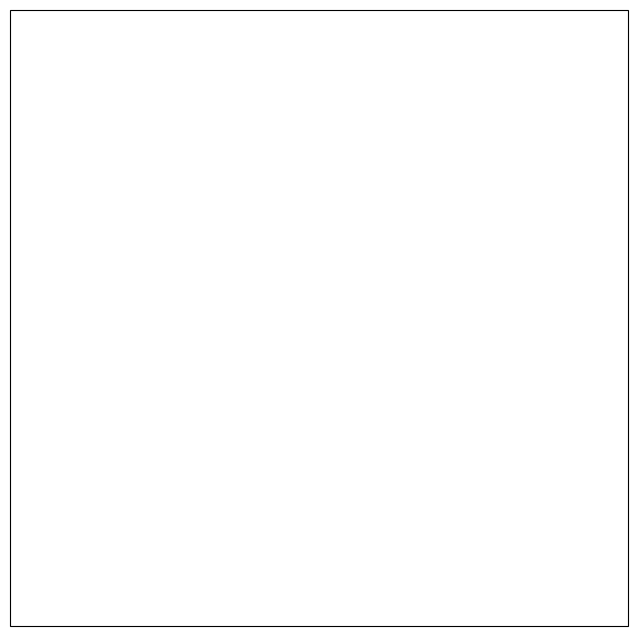

In [18]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax.set_extent([-180, 180, 30, 90], crs=ccrs.PlateCarree())

lat = ds.sic.lat.values
lon = ds.sic.lon.values

plt.contourf(lon, lat, ds.sic.isel(time=0))

plt.show()